# Fit Prophet model to the time dependency of cumulative sales for each store.

18:18:51 - cmdstanpy - INFO - Chain [1] start processing
18:18:51 - cmdstanpy - INFO - Chain [1] done processing
18:18:52 - cmdstanpy - INFO - Chain [1] start processing
18:18:52 - cmdstanpy - INFO - Chain [1] done processing
18:18:52 - cmdstanpy - INFO - Chain [1] start processing
18:18:52 - cmdstanpy - INFO - Chain [1] done processing
18:18:52 - cmdstanpy - INFO - Chain [1] start processing
18:18:53 - cmdstanpy - INFO - Chain [1] done processing
18:18:53 - cmdstanpy - INFO - Chain [1] start processing
18:18:53 - cmdstanpy - INFO - Chain [1] done processing
18:18:53 - cmdstanpy - INFO - Chain [1] start processing
18:18:54 - cmdstanpy - INFO - Chain [1] done processing
18:18:54 - cmdstanpy - INFO - Chain [1] start processing
18:18:54 - cmdstanpy - INFO - Chain [1] done processing
18:18:54 - cmdstanpy - INFO - Chain [1] start processing
18:18:54 - cmdstanpy - INFO - Chain [1] done processing
18:18:55 - cmdstanpy - INFO - Chain [1] start processing
18:18:55 - cmdstanpy - INFO - Chain [1]

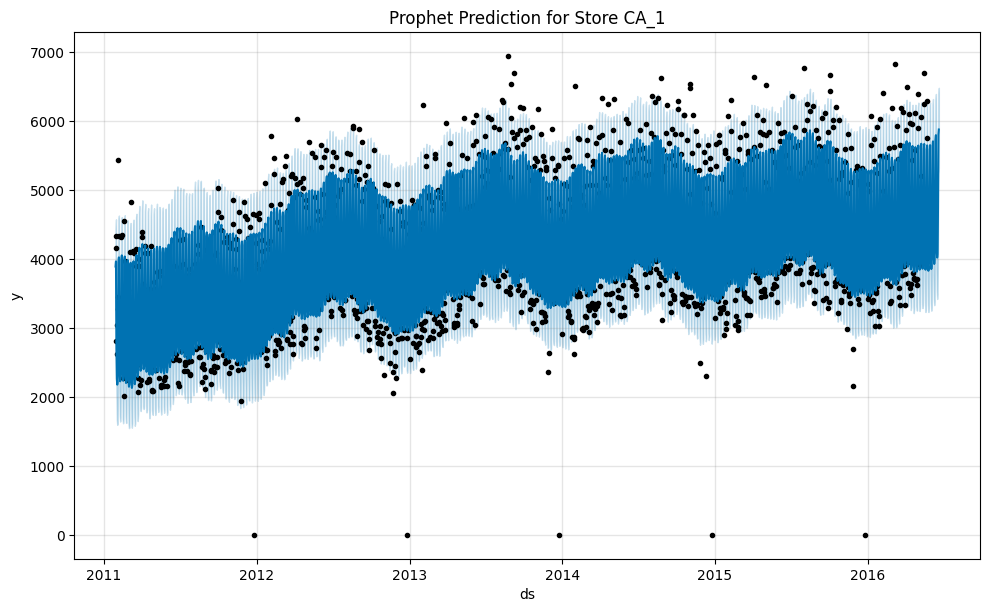

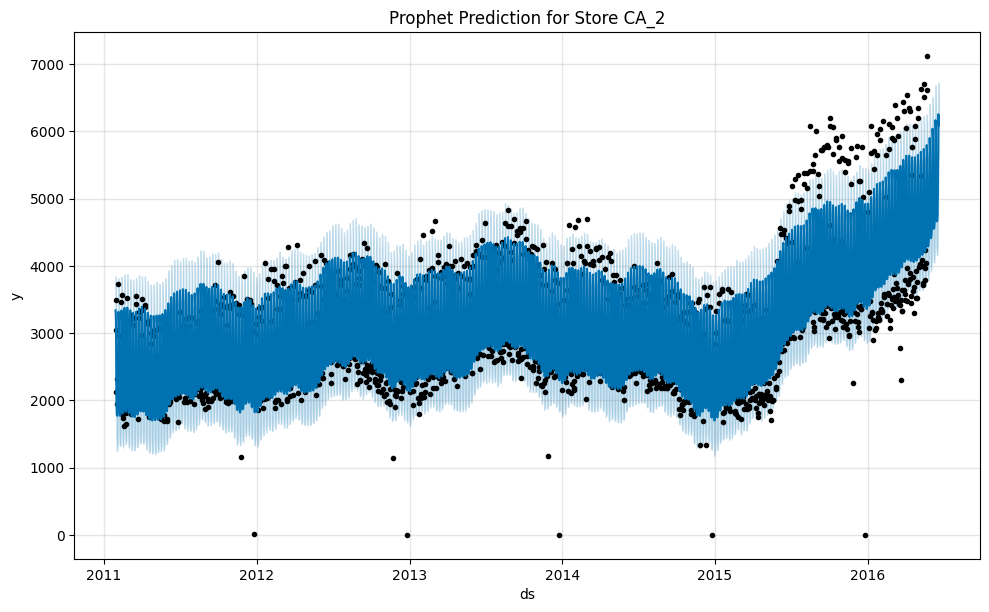

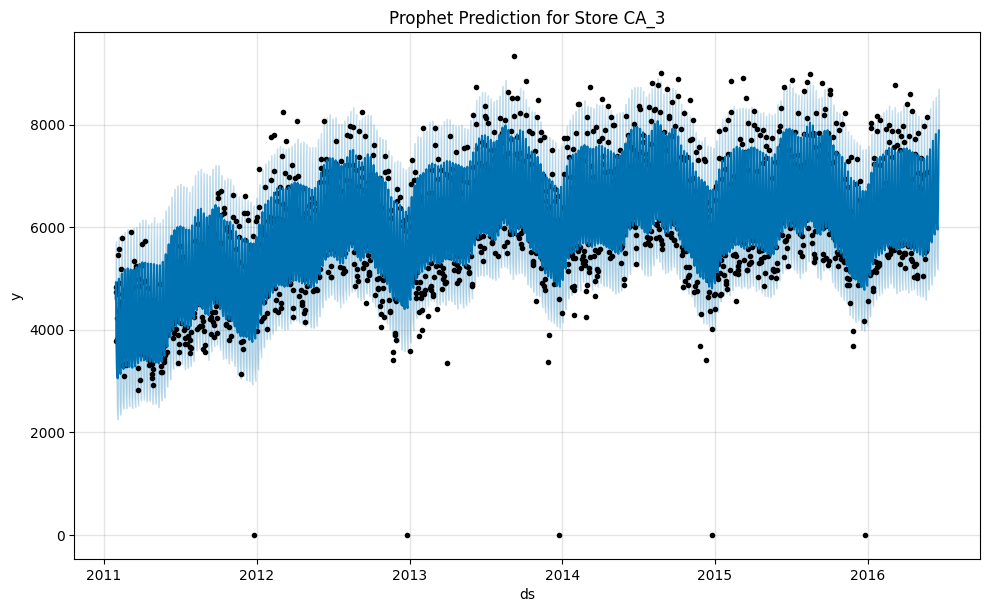

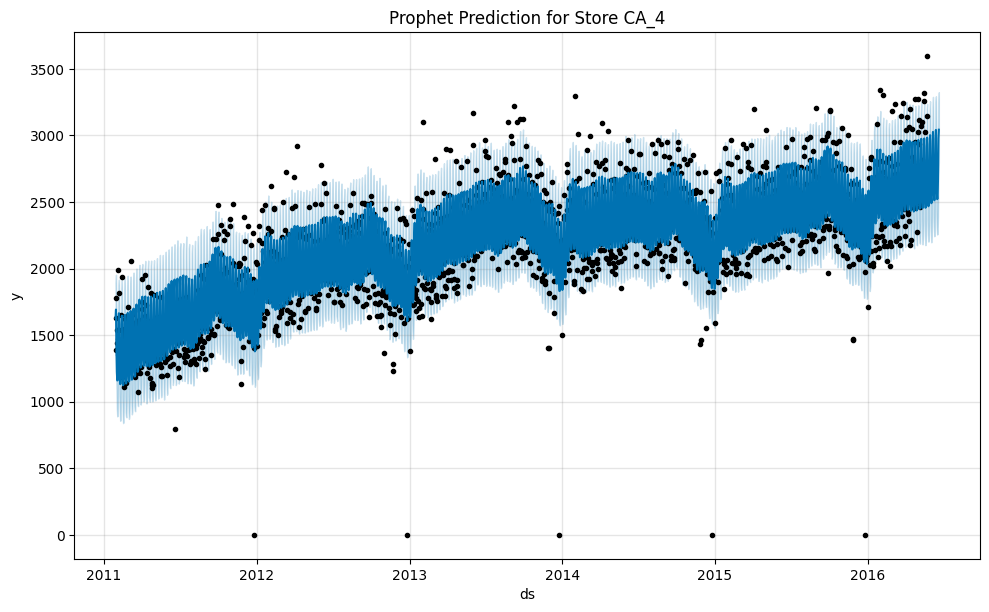

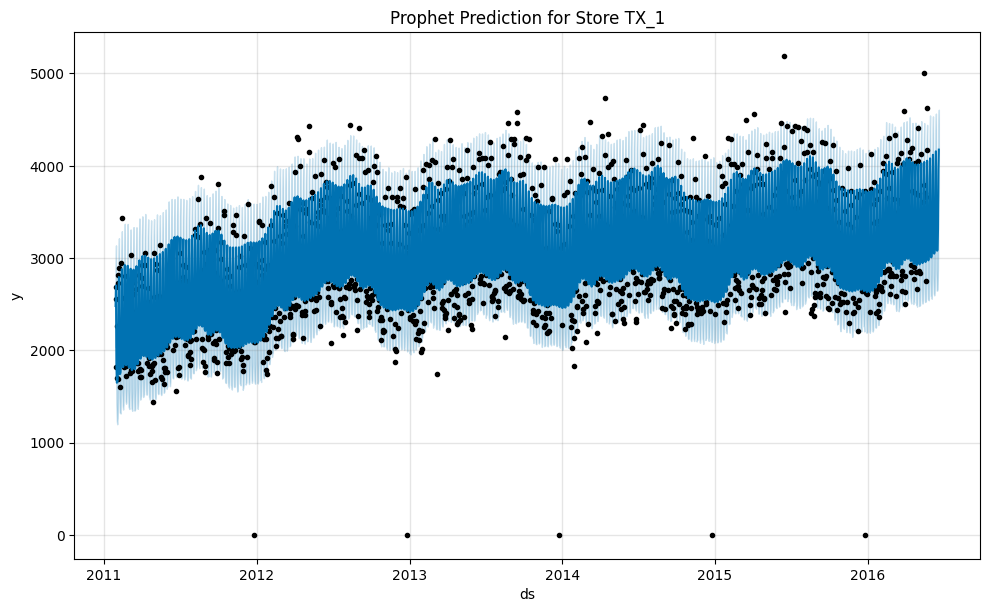

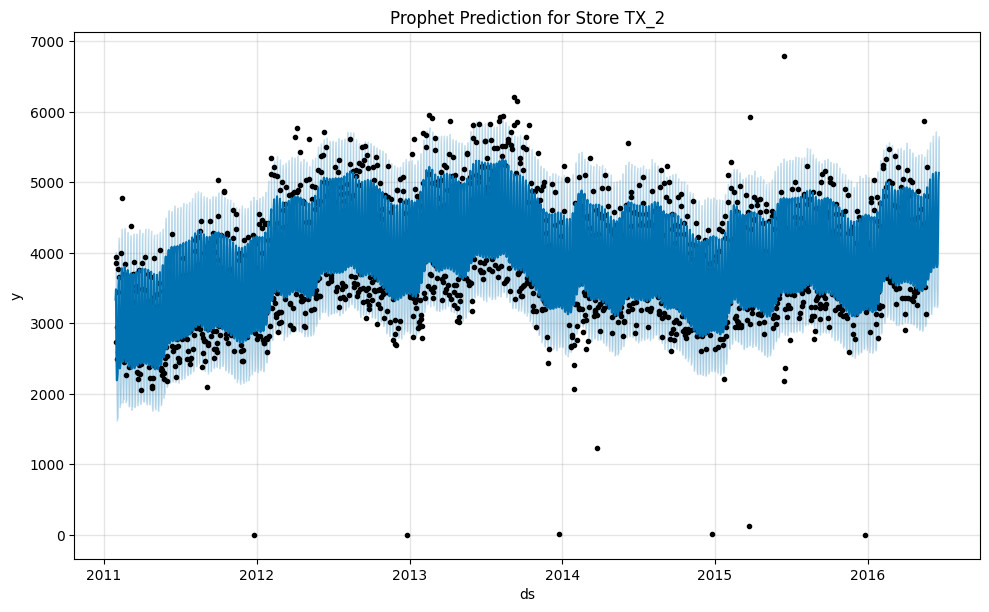

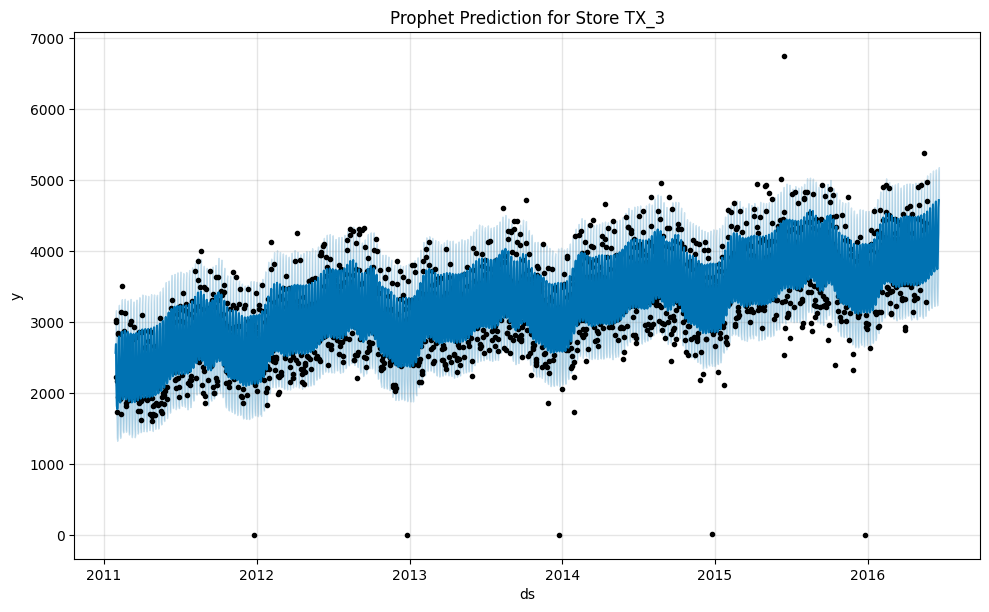

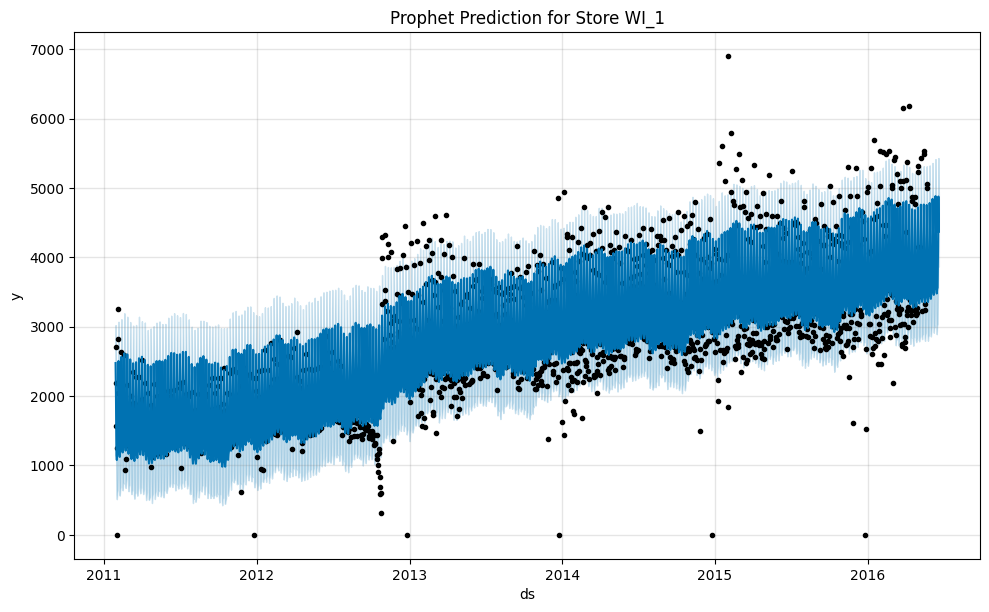

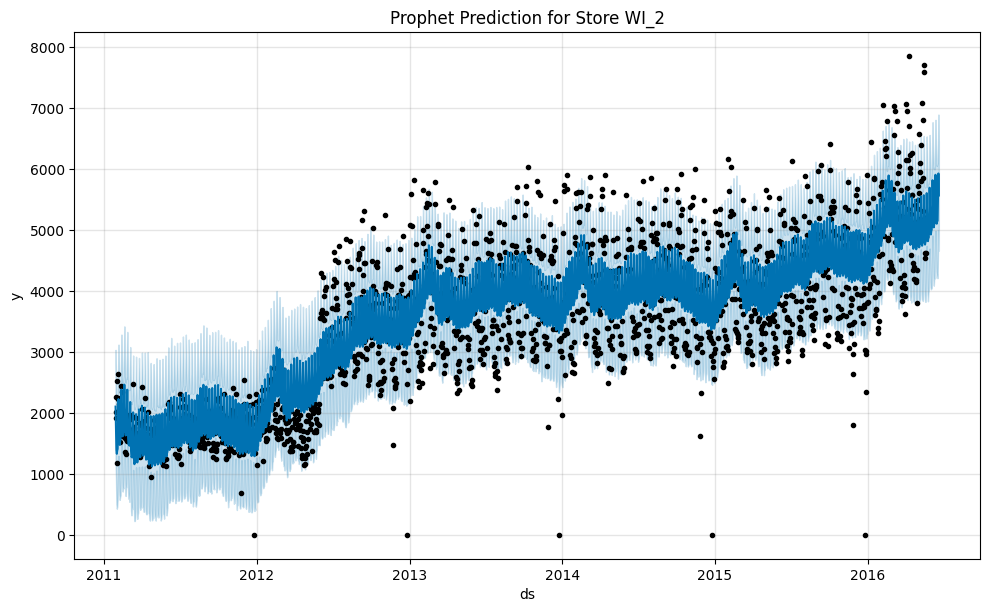

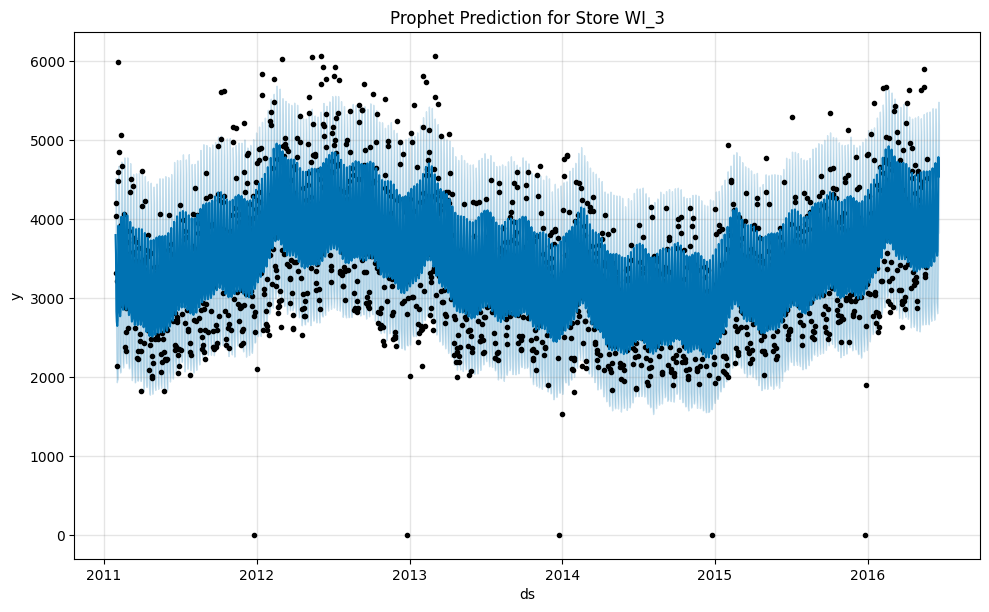

In [19]:
import os
import pandas as pd
from prophet import Prophet
import numpy as np

DATASETS_PATH = os.getenv("DATASETS_PATH") 

df_calendar = pd.read_csv(DATASETS_PATH + "/RetailOptimizationProject/m5-forecasting-accuracy/calendar.csv")

df_sell_prices = pd.read_csv(DATASETS_PATH + "/RetailOptimizationProject/m5-forecasting-accuracy/sell_prices.csv")

df_sales_train = pd.read_csv(DATASETS_PATH + "/RetailOptimizationProject/m5-forecasting-accuracy/sales_train_evaluation.csv")

# Get unique store IDs
store_ids = df_sales_train['store_id'].unique()

# Dictionary to hold per-store DataFrames ready for Prophet
store_dfs = {}

for store in store_ids:
    # Filter sales for this store
    df_store = df_sales_train[df_sales_train['store_id'] == store].copy()
    
    # Sum over items per day to get total store-level sales
    # Assuming day columns are like d_1, d_2, ..., d_1941
    day_cols = [col for col in df_store.columns if col.startswith('d_')]
    df_sum = df_store[day_cols].sum(axis=0).reset_index()
    
    # Rename columns to Prophet format: 'ds' = date, 'y' = value
    df_sum.columns = ['d', 'y']
    
    # Merge with calendar to get actual dates
    df_prophet = df_sum.merge(df_calendar[['d','date']], on='d', how='left')
    
    # Final Prophet DataFrame
    df_prophet = df_prophet[['date','y']].rename(columns={'date':'ds'})
    
    # Store in dictionary
    store_dfs[store] = df_prophet

store_models = {}

for store, df in store_dfs.items():
    model = Prophet()
    model.fit(df)
    store_models[store] = model

# Number of future days to forecast
future_days = 28

for store_id, df_store in store_dfs.items():
    # Get the fitted Prophet model
    model = store_models[store_id]
    
    # Create future dataframe (includes historical + future)
    future = model.make_future_dataframe(periods=future_days)
    
    # Predict
    forecast = model.predict(future)
    
    # Plot prediction for the store
    fig = model.plot(forecast)
    plt.title(f"Prophet Prediction for Store {store_id}")
    plt.show()
    